# Analys 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np
import os

# HUVUDINSTÄLLNINGAR
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

# 1. LADDA HELA DATASETET
print(" LADDAR IN FULLSTÄNDIG DATA ") 
if os.path.exists(FILE_PATH):
    # Vi struntar i 'usecols' här och laddar ALLT så vi slipper KeyErrors
    df = pd.read_csv(FILE_PATH, low_memory=False)
    
    # Skapa hjälp-kolumner direkt så de finns tillgängliga för alla grafer
    # 1. Konvertera fot till meter
    df['DistanceMeters'] = df['arenaAdjustedShotDistance'] * 0.3048
    
    # 2. Skapa avståndsgrupper (för stapeldiagrammet)
    bins_meter = [0, 3, 6, 9, 12, 15, 18]
    labels_meter = ['0-3m', '3-6m', '6-9m', '9-12m', '12-15m', '15-18m']
    df['DistanceGroupMeter'] = pd.cut(df['DistanceMeters'], bins=bins_meter, labels=labels_meter)
    
    print(f" Klar! {len(df)} rader inlästa.")
    print("Nu kan du köra alla analys-celler nedanför utan problem.")
    
else:
    print(" FEL: Filen hittades inte. Kontrollera sökvägen.")

 LADDAR IN FULLSTÄNDIG DATA 
 Klar! 119870 rader inlästa.
Nu kan du köra alla analys-celler nedanför utan problem.


Letar efter filen här: C:\Projects\Projektarbete\data\shots_2024.csv
Filen hittades! Laddar in data... (Vänta lite)

--- SUCCÉ! Filen är inläst ---
Antal rader (skott): 119870
Antal kolumner (variabler): 137

--- SÅ HÄR SER DATAN UT (De 5 första raderna) ---
   shotID  arenaAdjustedShotDistance  arenaAdjustedXCord  \
0       0                       52.0                57.0   
1       1                       33.0                71.0   
2       2                       48.0                48.0   
3       3                       58.0               -40.0   
4       4                       56.0               -35.0   

   arenaAdjustedXCordABS  arenaAdjustedYCord  arenaAdjustedYCordAbs  \
0                   57.0               -41.0                   41.0   
1                   71.0               -28.0                   28.0   
2                   48.0               -24.0                   24.0   
3                   40.0               -31.0                   31.0   
4                   35.0 

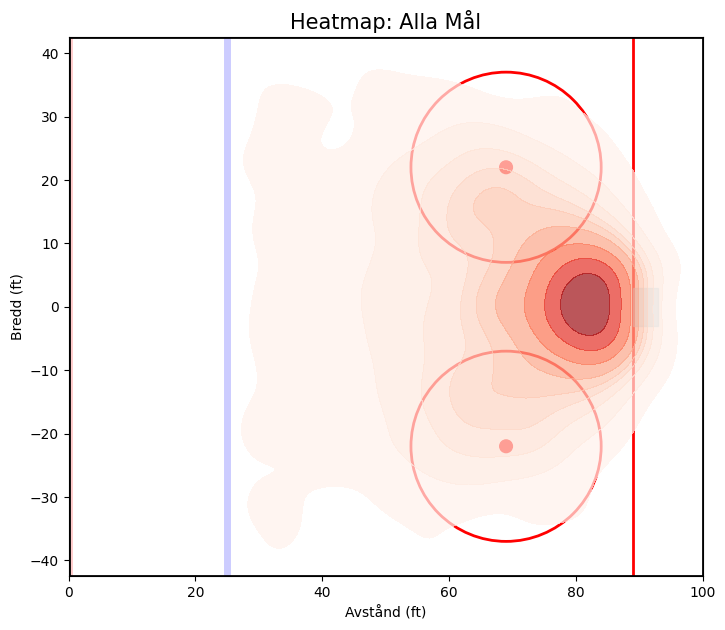

In [ ]:
# NHL API data loader och skott/mål-analys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import os


# Din sökväg till filen (anpassad för Windows)
file_path = r"C:\Projects\Projektarbete\data\shots_2024.csv"

print(f"Letar efter filen här: {file_path}")

# 1. Kolla om filen faktiskt finns där
if os.path.exists(file_path):
    print("Filen hittades! Laddar in data... (Vänta lite)")

    # 2. Läs in filen
    # low_memory=False behövs för att MoneyPuck-filer är stora
    df = pd.read_csv(file_path, low_memory=False)

    # 3. Visa resultatet i terminalen
    print("\n--- SUCCÉ! Filen är inläst ---")
    print(f"Antal rader (skott): {len(df)}")
    print(f"Antal kolumner (variabler): {len(df.columns)}")

    print("\n--- SÅ HÄR SER DATAN UT (De 5 första raderna) ---")
    # Detta gör att vi ser alla kolumner i utskriften
    pd.set_option('display.max_columns', None) 
    print(df.head())

else:
    print("\nFEL: Datorn hittar inte filen.")
    print("Kolla att filnamnet i mappen verkligen är 'shots_2024.csv'")

# Sökväg till din fil
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

# Välj vad vi ska titta på: "ALLA", "POWERPLAY", "RETURER"
FILTER_TYPE = "ALLA" 
# 

def draw_rink(ax):
    """Ritar en halv hockeyrink (Anfallszonen)"""
    # Isen (Vit bakgrund)
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="white", zorder=0))
    
    # Linjer
    ax.axvline(89, color="red", linestyle="-", linewidth=2, zorder=1) # Mållinje
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1)    # Blålinje (ca)
    ax.axvline(0, color="red", linewidth=5, alpha=0.2, zorder=1)      # Mittlinje
    
    # Målgården (Ljusblå)
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1))
    
    # Rinkens ram (Sargen)
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5))

    # Tekningscirklar (Röda)
    for y_pos in [-22, 22]:
        circle = patches.Circle((69, y_pos), 15, fill=False, edgecolor="red", linewidth=2, zorder=1)
        ax.add_patch(circle)
        dot = patches.Circle((69, y_pos), 1, color="red", zorder=1)
        ax.add_patch(dot)

def run_analysis():
    print(f"--- Läser in data från {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Hittar inte filen.")
        return

    # Läs in datan
    df = pd.read_csv(FILE_PATH, low_memory=False)
    
    # Filtrera: Vi vill bara se MÅL (goal == 1)
    goals = df[df['goal'] == 1].copy()
    print(f"Hittade totalt {len(goals)} mål i datan.")

    # Applicera ditt valda filter
    if FILTER_TYPE == "POWERPLAY":
        goals = goals[goals['isPowerPlay'] == 1]
        title = "Heatmap: Mål i Powerplay"
    elif FILTER_TYPE == "RETURER":
        goals = goals[goals['shotGeneratedRebound'] == 1]
        title = "Heatmap: Mål på Returer"
    else:
        title = "Heatmap: Alla Mål"

    print(f"Visar graf för: {len(goals)} st mål...")

    # RITA GRAFEN
    plt.figure(figsize=(10, 7))
    ax = plt.gca()
    
    # 1. Rita rinken
    draw_rink(ax)

    # 2. Skapa Heatmap
    # xCordAdjusted = Längdled (0-100), yCordAdjusted = Breddled (-42 till 42)
    sns.kdeplot(
        x=goals['xCordAdjusted'], 
        y=goals['yCordAdjusted'], 
        cmap="Reds",    # Färgskala (Röd)
        fill=True,      # Fyll färgen
        thresh=0.05,    # Ta bort de allra glesaste områdena
        alpha=0.7,      # Genomskinlighet
        zorder=2
    )

    # Inställningar
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title(title, fontsize=15)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal') # Håll proportionerna på rinken
    
    print("Visar grafen nu...")
    plt.show()

if __name__ == "__main__":
    run_analysis()

In [ ]:
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def list_all_variables():
    print(f"Läser in rubriker från {FILE_PATH} ")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # Vi läser bara in 1 rad för att det ska gå blixtsnabbt att hämta rubrikerna
    df_temp = pd.read_csv(FILE_PATH, nrows=1)
    columns = df_temp.columns.tolist()
    
    print(f"\nHittade totalt {len(columns)} st variabler:\n")
    print("-" * 30)
    
    # Skriv ut dem i en snygg lista
    for i, col in enumerate(columns):
        print(f"{i}: {col}")
        
    print("-" * 30)

if __name__ == "__main__":
    list_all_variables()

--- Läser in rubriker från C:\Projects\Projektarbete\data\shots_2024.csv ---

Hittade totalt 137 st variabler:

------------------------------
0: shotID
1: arenaAdjustedShotDistance
2: arenaAdjustedXCord
3: arenaAdjustedXCordABS
4: arenaAdjustedYCord
5: arenaAdjustedYCordAbs
6: averageRestDifference
7: awayEmptyNet
8: awayPenalty1Length
9: awayPenalty1TimeLeft
10: awaySkatersOnIce
11: awayTeamCode
12: awayTeamGoals
13: defendingTeamAverageTimeOnIce
14: defendingTeamAverageTimeOnIceOfDefencemen
15: defendingTeamAverageTimeOnIceOfDefencemenSinceFaceoff
16: defendingTeamAverageTimeOnIceOfForwards
17: defendingTeamAverageTimeOnIceOfForwardsSinceFaceoff
18: defendingTeamAverageTimeOnIceSinceFaceoff
19: defendingTeamDefencemenOnIce
20: defendingTeamForwardsOnIce
21: defendingTeamMaxTimeOnIce
22: defendingTeamMaxTimeOnIceOfDefencemen
23: defendingTeamMaxTimeOnIceOfDefencemenSinceFaceoff
24: defendingTeamMaxTimeOnIceOfForwards
25: defendingTeamMaxTimeOnIceOfForwardsSinceFaceoff
26: defendingTe

In [ ]:
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def count_total_stats():
    print(f" SAMMANSTÄLLNING AV DATA ")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # Ladda bara kolumnen 'goal' eftersom det är allt vi behöver för att räkna
    df = pd.read_csv(FILE_PATH, usecols=['goal'], low_memory=False)
    
    # Räkna ut statistiken
    total_shots = len(df)               # Antal rader = Antal skott
    total_goals = df['goal'].sum()      # Summan av alla 1:or = Antal mål
    missed_shots = total_shots - total_goals
    
    # Räkna ut den totala målprocenten för hela ligan
    league_average = (total_goals / total_shots) * 100

    # Visa resultatet
    print(f"Total mängd data (skott):  {total_shots:,}".replace(',', ' '))
    print(f"Totalt antal mål:          {total_goals:,}".replace(',', ' '))
    print(f"Antal räddningar/missar:   {missed_shots:,}".replace(',', ' '))
    print("-" * 30)
    print(f"Genomsnittlig målprocent i NHL: {league_average:.2f}%")

if __name__ == "__main__":
    count_total_stats()

--- SAMMANSTÄLLNING AV DATA ---
Total mängd data (skott):  119 870
Totalt antal mål:          8 428
Antal räddningar/missar:   111 442
------------------------------
Genomsnittlig målprocent i NHL: 7.03%


C:\Users\Amner\AppData\Local\Temp\ipykernel_40668\2941824020.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='shotType', y='Effektivitet', data=stats, palette='viridis')


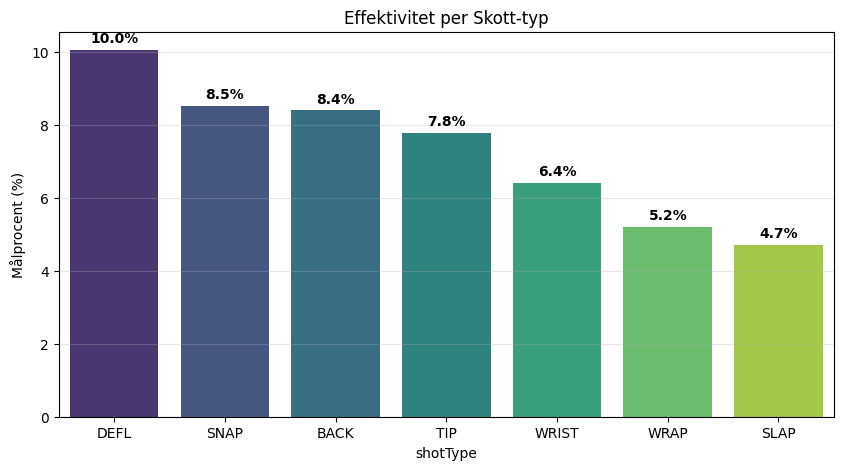

In [ ]:
# GRAF 1: VILKEN SKOTT-TYP ÄR BÄST? 

# Räkna ut statistik (Mål vs Totalt)
shots_per_type = df.groupby('shotType').size().reset_index(name='TotalShots')
goals_per_type = df[df['goal'] == 1].groupby('shotType').size().reset_index(name='Goals')

# Slå ihop och städa
stats = pd.merge(shots_per_type, goals_per_type, on='shotType', how='left').fillna(0)
stats = stats[stats['TotalShots'] > 500] # Ta bort ovanliga skott
stats['Effektivitet'] = (stats['Goals'] / stats['TotalShots']) * 100
stats = stats.sort_values('Effektivitet', ascending=False)

# Rita Graf 1
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='shotType', y='Effektivitet', data=stats, palette='viridis')

# Sätt siffror på staplarna
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 0.2, 
            f'{p.get_height():.1f}%', ha="center", fontweight='bold')

plt.title("Effektivitet per Skott-typ")
plt.ylabel("Målprocent (%)")
plt.grid(axis='y', alpha=0.3)
plt.show()

- DEFL (Deflection / Styrning - Passiv) – 10.0%
- SNAP (Snap Shot / "Snärtskott") – 8.5%
- BACK (Backhand) – 8.4%
- TIP (Tip-In / Styrning - Aktiv) – 7.8%
- WRIST (Wrist Shot / Handledsskott) – 6.4%
- WRAP (Wrap-around / "Köksvägen") – 5.2%
- SLAP (Slap Shot / Slagskott) – 4.7%

C:\Users\Amner\AppData\Local\Temp\ipykernel_40668\2414706216.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='DistanceGroup', y='Effektivitet', data=dist_stats, palette='coolwarm')


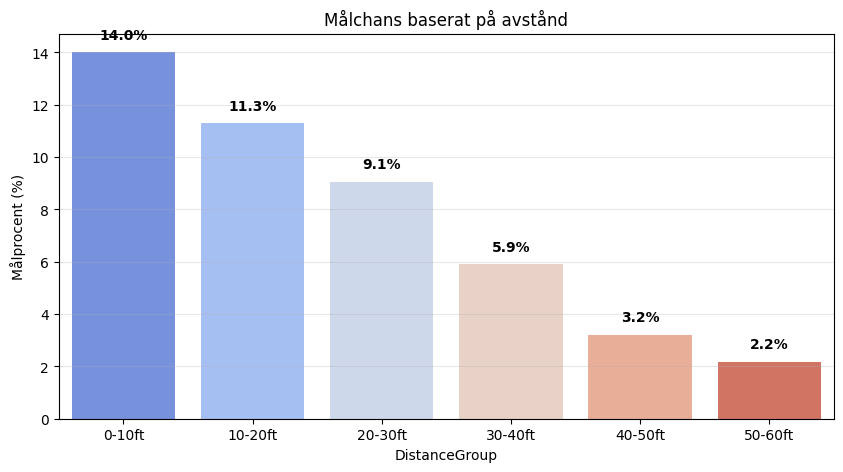

In [ ]:
# GRAF 2: HUR PÅVERKAR AVSTÅNDET?

# Skapa grupper för avstånd (0-10ft, 10-20ft osv)
bins = [0, 10, 20, 30, 40, 50, 60]
labels = ['0-10ft', '10-20ft', '20-30ft', '30-40ft', '40-50ft', '50-60ft']
df['DistanceGroup'] = pd.cut(df['arenaAdjustedShotDistance'], bins=bins, labels=labels)

# Räkna ut %
dist_stats = df.groupby('DistanceGroup', observed=True)['goal'].mean() * 100
dist_stats = dist_stats.reset_index(name='Effektivitet')

# Rita Graf 2
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(x='DistanceGroup', y='Effektivitet', data=dist_stats, palette='coolwarm')

for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width()/2., p.get_height() + 0.5, 
            f'{p.get_height():.1f}%', ha="center", fontweight='bold')

plt.title("Målchans baserat på avstånd")
plt.ylabel("Målprocent (%)")
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\Amner\AppData\Local\Temp\ipykernel_40668\1414437772.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='DistanceGroupMeter', y='Effektivitet', data=dist_stats_m, palette='coolwarm')


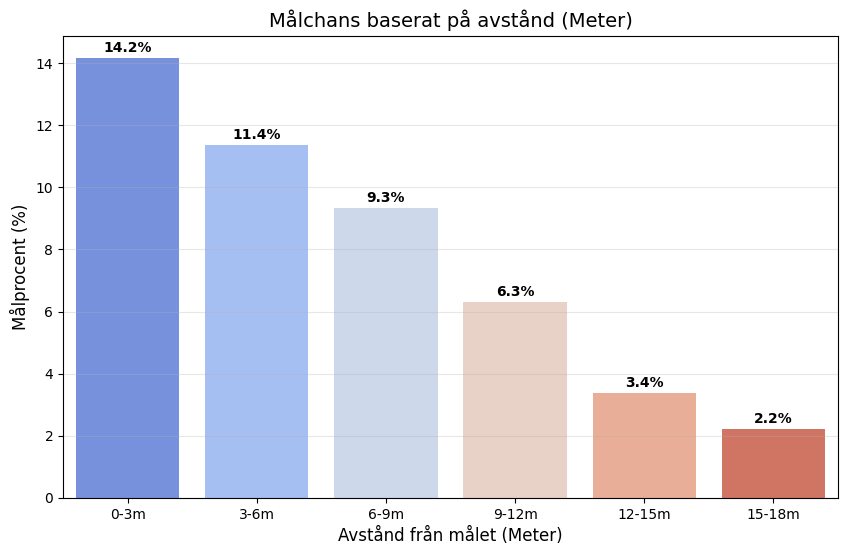

In [ ]:
# GRAF 2: MÅLCHANS BASERAT PÅ AVSTÅND (I METER) 

# 1. Skapa en ny kolumn: Konvertera fot till meter
# Vi multiplicerar avståndet med 0.3048
df['DistanceMeters'] = df['arenaAdjustedShotDistance'] * 0.3048

# 2. Skapa grupper för meter
# Vi kör 3-meters intervaller (eftersom 10 fot är ca 3 meter). 
# 0-18 meter täcker in ungefär samma yta som 0-60 fot.
bins_meter = [0, 3, 6, 9, 12, 15, 18]
labels_meter = ['0-3m', '3-6m', '6-9m', '9-12m', '12-15m', '15-18m']

# Dela in datan i de nya grupperna
df['DistanceGroupMeter'] = pd.cut(df['DistanceMeters'], bins=bins_meter, labels=labels_meter)

# 3. Räkna ut effektivitet (%)
dist_stats_m = df.groupby('DistanceGroupMeter', observed=True)['goal'].mean() * 100
dist_stats_m = dist_stats_m.reset_index(name='Effektivitet')

# 4. Rita Grafen
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='DistanceGroupMeter', y='Effektivitet', data=dist_stats_m, palette='coolwarm')

# Lägg till siffror på staplarna
for p in ax2.patches:
    # Vi kollar så att stapeln har en höjd (finns data) innan vi skriver text
    if p.get_height() > 0:
        ax2.text(p.get_x() + p.get_width()/2., p.get_height() + 0.2, 
                f'{p.get_height():.1f}%', ha="center", fontweight='bold')

plt.title("Målchans baserat på avstånd (Meter)", fontsize=14)
plt.ylabel("Målprocent (%)", fontsize=12)
plt.xlabel("Avstånd från målet (Meter)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Skapar Hexbin-karta med procentsatser...
Visar grafen...


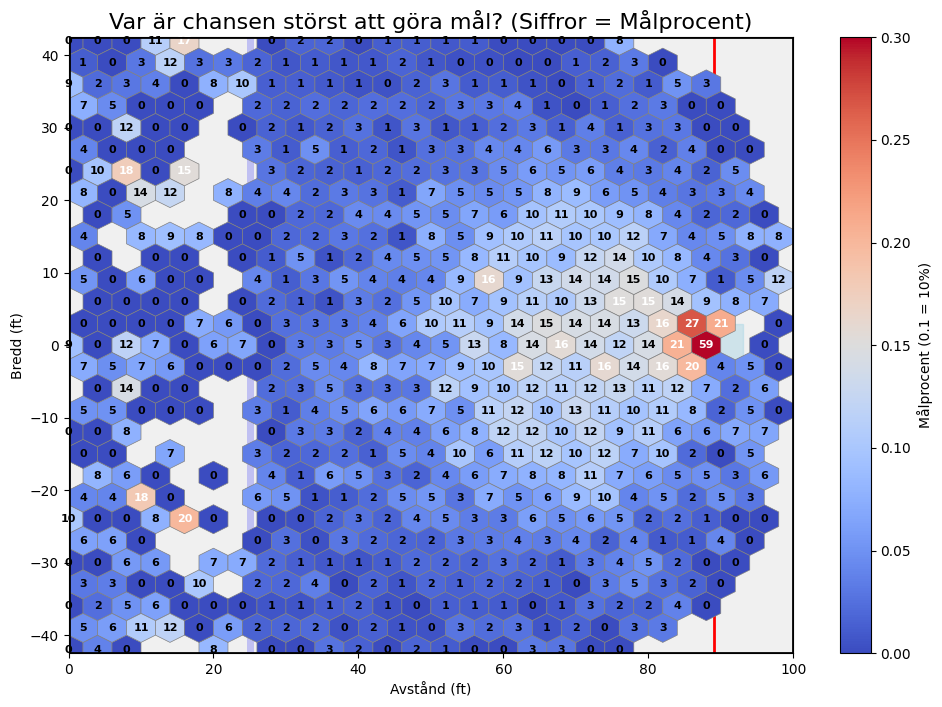

In [ ]:
import numpy as np # Behövs för att räkna ut medelvärdet i hexagonerna

# INSTÄLLNINGAR 
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"
# 

def load_data():
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return None
    # Vi laddar de kolumner vi behöver
    cols = ['xCordAdjusted', 'yCordAdjusted', 'goal']
    return pd.read_csv(FILE_PATH, usecols=cols, low_memory=False)

def draw_rink(ax):
    """Ritar rinken i bakgrunden"""
    # Isen
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="#f0f0f0", zorder=0))
    # Linjer
    ax.axvline(89, color="red", linewidth=2, zorder=1) # Mållinje
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1) # Blålinje
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1)) # Målgård
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5)) # Sarg

def plot_hexbin_efficiency(df):
    print("Skapar Hexbin-karta med procentsatser...")
    
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    
    # 1. Rita rinken
    draw_rink(ax)

    # --- SKAPA HEXBIN-KARTAN ---
    # gridsize: Hur många hexagoner brett rutnätet ska vara (högre siffra = mindre rutor)
    # C: Vilken data vi ska analysera (goal = 1 eller 0)
    # reduce_C_function: Vad vi ska göra med datan i varje ruta. np.mean räknar ut snittet (procenten).
    # cmap: Färgskalan. 'coolwarm' går från blått (kallt/låg %) till rött (varmt/hög %)
    hb = ax.hexbin(
        df['xCordAdjusted'], 
        df['yCordAdjusted'], 
        C=df['goal'], 
        gridsize=25, 
        reduce_C_function=np.mean, 
        cmap='coolwarm',
        edgecolors='gray', # Tunn grå kant runt varje hexagon gör det tydligare
        linewidths=0.5,
        mincnt=10, # VIKTIGT: Visa bara hexagoner där minst 10 skott har skjutits (tar bort brus)
        zorder=2,
        vmax=0.3 # Tak för färgskalan. Allt över 30% blir max-rött. Detta gör att vi ser skillnad på 5% och 15% bättre.
    )

    # LÄGG TILL SIFFROR (Procentsatser) 
    # Vi hämtar datan från hexbin-objektet vi just skapade
    centers = hb.get_offsets() # Var mitten på varje hexagon är
    values = hb.get_array()    # Vilket värde (procent) den har

    # Loopa igenom alla hexagoner och skriv ut text
    for i in range(len(centers)):
        xc, yc = centers[i] # Koordinater
        val = values[i]     # Värdet (t.ex. 0.125 för 12.5%)
        
        # Skriv bara ut om värdet inte är "Not a Number" (NaN)
        if not np.isnan(val):
            # Om procenten är hög (mörk färg), använd vit text. Annars svart text.
            text_color = 'white' if val > 0.15 else 'black'
            
            # Format: val*100 gör om 0.12 till 12. :.0f betyder "inga decimaler".
            # Vi skriver t.ex. "12" istället för "12%" för att spara plats.
            ax.text(xc, yc, f'{val*100:.0f}', ha='center', va='center', 
                    color=text_color, fontsize=8, fontweight='bold', zorder=3)

    # Lägg till en färg-skala på sidan så man förstår färgerna
    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Målprocent (0.1 = 10%)')

    # Snygga till grafen
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title("Var är chansen störst att göra mål? (Siffror = Målprocent)", fontsize=16)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal')
    
    print("Visar grafen...")
    plt.show()

# HUVUDPROGRAM 
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        plot_hexbin_efficiency(df)

--- Analyserar RETURER från C:\Projects\Projektarbete\data\shots_2024.csv ---
Hittade 8937 st returer.
Genomsnittlig målprocent på dessa: 11.5%


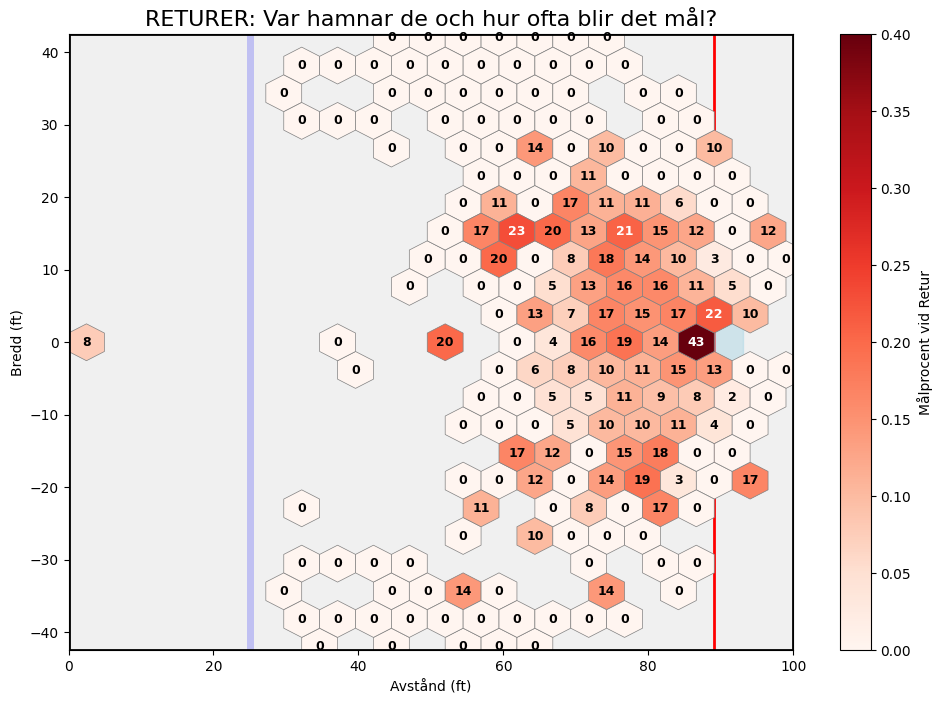

In [ ]:
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def plot_rebound_map():
    print(f"--- Analyserar RETURER från {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # 1. Ladda data (Nu behöver vi 'shotRebound'-kolumnen också)
    cols = ['xCordAdjusted', 'yCordAdjusted', 'goal', 'shotRebound']
    df = pd.read_csv(FILE_PATH, usecols=cols, low_memory=False)
    
    # 2. Filtrera: Behåll bara skott som ÄR returer
    # (shotRebound == 1 betyder att skottet är en retur på ett tidigare skott)
    rebounds = df[df['shotRebound'] == 1]
    
    print(f"Hittade {len(rebounds)} st returer.")
    print(f"Genomsnittlig målprocent på dessa: {rebounds['goal'].mean()*100:.1f}%")

    # RITA KARTAN
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Rita rinken (bakgrund)
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="#f0f0f0", zorder=0))
    ax.axvline(89, color="red", linewidth=2, zorder=1)
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1)
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1))
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5))

    # Skapa Hexbin-karta för RETURER
    hb = ax.hexbin(
        rebounds['xCordAdjusted'], 
        rebounds['yCordAdjusted'], 
        C=rebounds['goal'], 
        gridsize=20, # Lite större rutor för att fånga upp datan bättre
        reduce_C_function=np.mean, 
        cmap='Reds', # Enbart röda toner för att visa "fara"
        edgecolors='gray',
        linewidths=0.5,
        mincnt=5, # Visa rutor där minst 5 returer skett
        zorder=2,
        vmax=0.4 # Sätter taket till 40% för att se nyanser (returer har ofta väldigt hög %)
    )

    # Skriv ut siffror (Procent)
    centers = hb.get_offsets()
    values = hb.get_array()
    
    for i in range(len(centers)):
        xc, yc = centers[i]
        val = values[i]
        if not np.isnan(val):
            # Vit text om det är mörkrött, annars svart
            text_color = 'white' if val > 0.2 else 'black'
            ax.text(xc, yc, f'{val*100:.0f}', ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold', zorder=3)

    # Färgskala och titlar
    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Målprocent vid Retur')
    
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title(f"RETURER: Var hamnar de och hur ofta blir det mål?", fontsize=16)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal')
    
    plt.show()

# Kör funktionen
plot_rebound_map()

--- Analyserar Målgörande skott utan returer (Ej returer) från C:\Projects\Projektarbete\data\shots_2024.csv ---
Hittade 110933 st direktskott.
Genomsnittlig målprocent på dessa: 6.7%


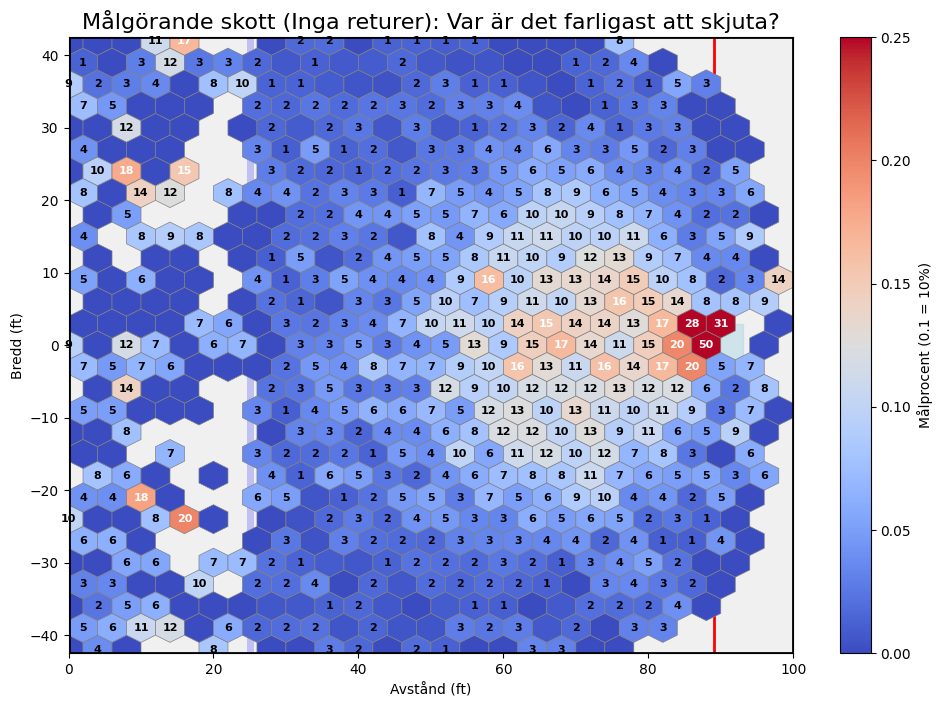

In [ ]:
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def plot_non_rebound_map():
    print(f"--- Analyserar Målgörande skott utan returer (Ej returer) från {FILE_PATH} ---")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # 1. Ladda data
    cols = ['xCordAdjusted', 'yCordAdjusted', 'goal', 'shotRebound']
    df = pd.read_csv(FILE_PATH, usecols=cols, low_memory=False)
    
    # 2. Filtrera: Behåll bara skott som INTE är returer (shotRebound == 0)
    non_rebounds = df[df['shotRebound'] == 0]
    
    print(f"Hittade {len(non_rebounds)} st direktskott.")
    print(f"Genomsnittlig målprocent på dessa: {non_rebounds['goal'].mean()*100:.1f}%")

    # SRITA KARTAN
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Rita rinken
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="#f0f0f0", zorder=0))
    ax.axvline(89, color="red", linewidth=2, zorder=1)
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1)
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1))
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5))

    # Skapa Hexbin-karta för DIREKTSKOTT
    hb = ax.hexbin(
        non_rebounds['xCordAdjusted'], 
        non_rebounds['yCordAdjusted'], 
        C=non_rebounds['goal'], 
        gridsize=25, 
        reduce_C_function=np.mean, 
        cmap='coolwarm', # Använder blå-röd skala här för att visa kalla/varma zoner tydligt
        edgecolors='gray',
        linewidths=0.5,
        mincnt=10, 
        zorder=2,
        vmax=0.25 # Sätter taket lägre (25%) eftersom direktskott sällan har lika hög % som returer
    )

    # Skriv ut siffror
    centers = hb.get_offsets()
    values = hb.get_array()
    
    for i in range(len(centers)):
        xc, yc = centers[i]
        val = values[i]
        if not np.isnan(val):
            # Vit text om det är mörkrött, annars svart
            text_color = 'white' if val > 0.15 else 'black'
            # Visa bara siffror om det är över 1% (för att slippa massa nollor ute i hörnen)
            if val > 0.01:
                ax.text(xc, yc, f'{val*100:.0f}', ha='center', va='center', 
                        color=text_color, fontsize=8, fontweight='bold', zorder=3)

    # Färgskala och titlar
    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Målprocent (0.1 = 10%)')
    
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title(f"Målgörande skott (Inga returer): Var är det farligast att skjuta?", fontsize=16)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal')
    
    plt.show()

# Kör funktionen
plot_non_rebound_map()

--- Analyserar SKOTT PÅ PASSNING (Inom 3 sek) ---
Hittade 7910 st snabba skott på pass.
Genomsnittlig målprocent: 5.2%


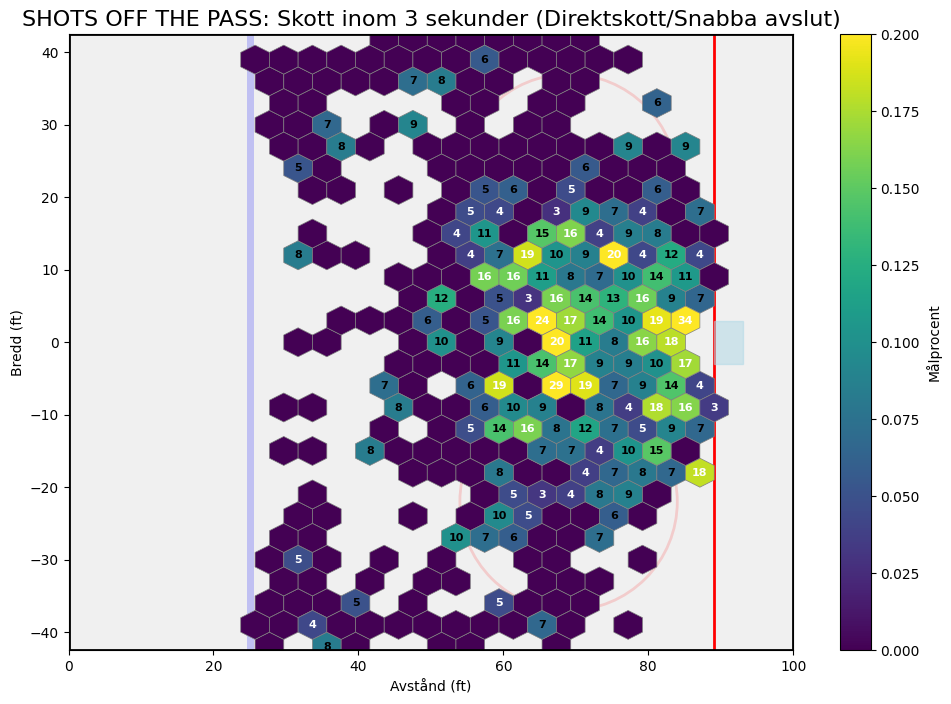

In [ ]:
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def plot_improved_onetimer_map():
    print(f"--- Analyserar SKOTT PÅ PASSNING (Inom 3 sek) ---")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # 1. Ladda data (Vi lägger till 'shotType' och 'lastEventCategory')
    cols = ['xCordAdjusted', 'yCordAdjusted', 'goal', 'shotRebound', 
            'timeSinceLastEvent', 'shotType', 'lastEventCategory']
    df = pd.read_csv(FILE_PATH, usecols=cols, low_memory=False)
    
    # 2. FILTRERING: Den nya definitionen
    quick_shots = df[
        (df['shotRebound'] == 0) &                  # Inte en retur
        (df['timeSinceLastEvent'] <= 3.0) &         # Inom 3 sekunder (Passningens tid inräknad)
        (df['lastEventCategory'] != 'FAC') &        # Inte direkt efter tekning
        (df['shotType'].isin(['SLAP', 'SNAP', 'WRIST'])) # Ta bort backhand/köksvägen
    ]
    
    print(f"Hittade {len(quick_shots)} st snabba skott på pass.")
    print(f"Genomsnittlig målprocent: {quick_shots['goal'].mean()*100:.1f}%")

    # SRITA KARTAN 
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Rita rinken
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="#f0f0f0", zorder=0))
    ax.axvline(89, color="red", linewidth=2, zorder=1)
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1)
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1))
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5))
    
    # Markera cirklarna där one-timers ofta sker
    for y_pos in [-22, 22]:
        ax.add_patch(patches.Circle((69, y_pos), 15, fill=False, edgecolor="red", linewidth=2, alpha=0.15))

    # Skapa Hexbin-karta
    hb = ax.hexbin(
        quick_shots['xCordAdjusted'], 
        quick_shots['yCordAdjusted'], 
        C=quick_shots['goal'], 
        gridsize=25, 
        reduce_C_function=np.mean, 
        cmap='viridis', # Ny färgskala (Gul-Grön-Lila) för att variera oss
        edgecolors='gray',
        linewidths=0.5,
        mincnt=10, # Nu när vi har mer data kan vi höja gränsen för att få "renare" karta
        zorder=2,
        vmax=0.20 # Tak på 20%
    )

    # Skriv ut siffror
    centers = hb.get_offsets()
    values = hb.get_array()
    
    for i in range(len(centers)):
        xc, yc = centers[i]
        val = values[i]
        if not np.isnan(val):
            # Anpassa textfärg efter viridis-skalan (Ljus gul = mörk text, Mörk lila = vit text)
            text_color = 'white' if val < 0.05 or val > 0.15 else 'black'
            
            # Visa bara relevanta procentsatser
            if val > 0.02:
                ax.text(xc, yc, f'{val*100:.0f}', ha='center', va='center', 
                        color=text_color, fontsize=8, fontweight='bold', zorder=3)

    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Målprocent')
    
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title(f"SHOTS OFF THE PASS: Skott inom 3 sekunder (Direktskott/Snabba avslut)", fontsize=16)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal')
    
    plt.show()

plot_improved_onetimer_map()

--- Analyserar VOLYM: Antal mål på passnings-skott ---
Hittade totalt 410 st MÅL som gjordes på direktskott/snabba avslut.


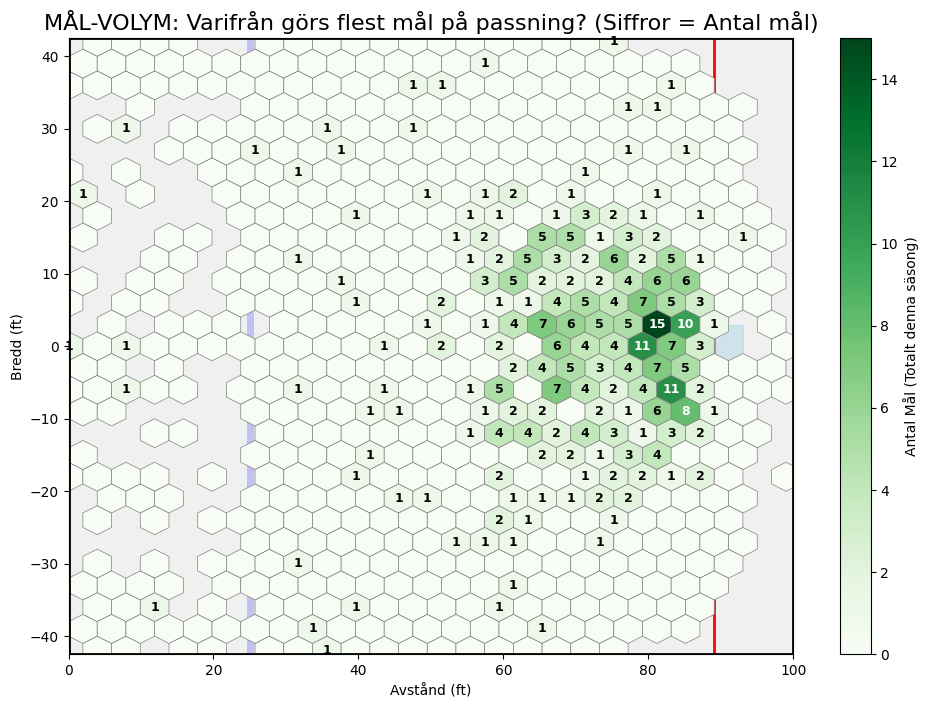

In [ ]:
# INSTÄLLNINGAR 
FILE_PATH = r"C:\Projects\Projektarbete\data\shots_2024.csv"

def plot_onetimer_volume_map():
    print(f"--- Analyserar VOLYM: Antal mål på passnings-skott ---")
    
    if not os.path.exists(FILE_PATH):
        print("FEL: Filen hittades inte!")
        return

    # 1. Ladda data
    cols = ['xCordAdjusted', 'yCordAdjusted', 'goal', 'shotRebound', 
            'timeSinceLastEvent', 'shotType', 'lastEventCategory']
    df = pd.read_csv(FILE_PATH, usecols=cols, low_memory=False)
    
    # 2. FILTRERING (Samma som förra, "Shots off the Pass")
    quick_shots = df[
        (df['shotRebound'] == 0) &                  
        (df['timeSinceLastEvent'] <= 3.0) &         
        (df['lastEventCategory'] != 'FAC') &        
        (df['shotType'].isin(['SLAP', 'SNAP', 'WRIST']))
    ]
    
    # Räkna totalt antal mål i urvalet
    total_goals = quick_shots['goal'].sum()
    print(f"Hittade totalt {total_goals} st MÅL som gjordes på direktskott/snabba avslut.")

    # --- RITA KARTAN ---
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Rita rinken
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, color="#f0f0f0", zorder=0))
    ax.axvline(89, color="red", linewidth=2, zorder=1)
    ax.axvline(25, color="blue", linewidth=5, alpha=0.2, zorder=1)
    ax.add_patch(patches.Rectangle((89, -3), 4, 6, color="lightblue", alpha=0.5, zorder=1))
    ax.add_patch(patches.Rectangle((0, -42.5), 100, 85, fill=False, edgecolor="black", linewidth=2, zorder=5))
    
    for y_pos in [-22, 22]:
        ax.add_patch(patches.Circle((69, y_pos), 15, fill=False, edgecolor="red", linewidth=2, alpha=0.15))

    # Skapa Hexbin-karta (Nu räknar vi ANTAL mål)
    hb = ax.hexbin(
        quick_shots['xCordAdjusted'], 
        quick_shots['yCordAdjusted'], 
        C=quick_shots['goal'], 
        gridsize=25, 
        reduce_C_function=np.sum,  # VIKTIGT: Vi summerar antalet mål (1+1+1...) istället för medelvärde
        cmap='Greens',             # Använder grön skala för "Money" / Antal mål
        edgecolors='gray',
        linewidths=0.5,
        mincnt=1,                  # Visa rutan så fort det gjorts minst 1 mål
        zorder=2,
        vmax=None                  # Inget tak, låt färgskalan anpassa sig efter maxvärdet
    )

    # Skriv ut siffror (ANTAL MÅL)
    centers = hb.get_offsets()
    values = hb.get_array()
    
    for i in range(len(centers)):
        xc, yc = centers[i]
        val = values[i]
        
        # Visa bara om det gjorts minst 1 mål i rutan
        if val >= 1:
            # Gör texten vit om det är mörkgrönt, annars svart
            text_color = 'white' if val > values.max() * 0.5 else 'black'
            
            # Format: {int(val)} gör om 5.0 till 5 (heltal)
            ax.text(xc, yc, f'{int(val)}', ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold', zorder=3)

    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Antal Mål (Totalt denna säsong)')
    
    plt.xlim(0, 100)
    plt.ylim(-42.5, 42.5)
    plt.title(f"MÅL-VOLYM: Varifrån görs flest mål på passning? (Siffror = Antal mål)", fontsize=16)
    plt.xlabel("Avstånd (ft)")
    plt.ylabel("Bredd (ft)")
    plt.gca().set_aspect('equal')
    
    plt.show()

plot_onetimer_volume_map()